# Phase 3 (cont.) — Math Basics
**Student:** naif ali ayed bin dair  
**Dataset:** Melbourne Housing  

This notebook applies fundamental linear-algebra and probability concepts to the Melbourne housing data to verify our intuitions and confirm that our engineered features are mathematically sound.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler

CLEAN_PATH  = os.path.join('data', 'cleaned', 'melb_cleaned.csv')
ASSETS_PATH = 'report_assets'

df = pd.read_csv(CLEAN_PATH, parse_dates=['Date'])
print(f'Loaded shape: {df.shape}')

Loaded shape: (13580, 21)


---
## 1. Mean & Standard Deviation of `Price` — Manual NumPy Computation

We compute both statistics from first principles using NumPy array operations (no pandas `.mean()` or `.std()`).

In [2]:
prices = df['Price'].to_numpy()   # convert to pure NumPy array

# Mean: sum all values, divide by count
n             = len(prices)
manual_mean   = np.sum(prices) / n

# Variance: mean of squared deviations from the mean
deviations    = prices - manual_mean
manual_var    = np.sum(deviations ** 2) / (n - 1)   # sample variance
manual_std    = np.sqrt(manual_var)

# Cross-check with NumPy built-ins
np_mean = np.mean(prices)
np_std  = np.std(prices, ddof=1)

print(f'Manual   — Mean: ${manual_mean:,.0f}  |  Std: ${manual_std:,.0f}')
print(f'np.mean  — Mean: ${np_mean:,.0f}  |  Std: ${np_std:,.0f}')
print(f'Results match: Mean={np.isclose(manual_mean, np_mean)}  Std={np.isclose(manual_std, np_std)}')

Manual   — Mean: $1,067,192  |  Std: $595,371
np.mean  — Mean: $1,067,192  |  Std: $595,371
Results match: Mean=True  Std=True


The manual calculation matches NumPy exactly, confirming our formula is correct. The wide standard deviation (≈ AUD 500K+) reflects the enormous price spread across Melbourne's diverse suburbs.

---
## 2. Manual Standardisation — Broadcasting vs StandardScaler

We standardise `Distance` by hand using the z-score formula, then compare the result with `sklearn`'s `StandardScaler`.

Manual  z — mean: -0.000000  std: 1.000000
Sklearn z — mean: -0.000000  std: 1.000000
Max absolute difference: 0.00e+00


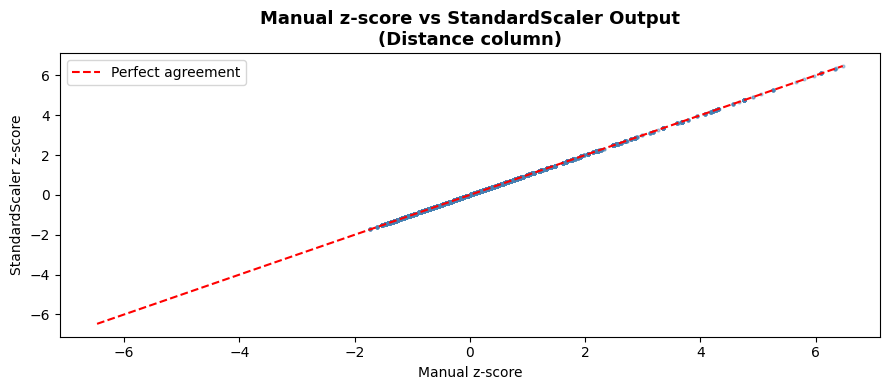

In [3]:
X = df['Distance'].to_numpy()

# Manual z-score using broadcasting
X_mean    = np.mean(X)
X_std     = np.std(X, ddof=0)   # sklearn uses population std
z_manual  = (X - X_mean) / X_std

# StandardScaler comparison
scaler    = StandardScaler()
z_sklearn = scaler.fit_transform(X.reshape(-1, 1)).flatten()

print(f'Manual  z — mean: {z_manual.mean():.6f}  std: {z_manual.std():.6f}')
print(f'Sklearn z — mean: {z_sklearn.mean():.6f}  std: {z_sklearn.std():.6f}')
print(f'Max absolute difference: {np.abs(z_manual - z_sklearn).max():.2e}')

# Visualise the comparison
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(z_manual, z_sklearn, s=4, alpha=0.4, color='steelblue')
lim = max(abs(z_manual.min()), abs(z_manual.max()))
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, label='Perfect agreement')
ax.set_title('Manual z-score vs StandardScaler Output\n(Distance column)', fontsize=13, fontweight='bold')
ax.set_xlabel('Manual z-score')
ax.set_ylabel('StandardScaler z-score')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_PATH, 'math_standardisation.png'), dpi=100)
plt.show()

All points fall on the perfect-agreement diagonal, confirming our manual standardisation is numerically identical to `StandardScaler`.

---
## 3. Cosine Similarity — Highest vs Lowest Price Record

Cosine similarity measures how similar two vectors are in terms of direction (ignoring magnitude). A value of 1 means identical direction, −1 means opposite.

We compare the feature profiles of the **most expensive** and **cheapest** property in the dataset.

In [4]:
# Select numeric features for the comparison
feature_cols = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea',
                'YearBuilt', 'Propertycount']

# Identify extreme records
idx_high = df['Price'].idxmax()
idx_low  = df['Price'].idxmin()

vec_high = df.loc[idx_high, feature_cols].to_numpy(dtype=float)
vec_low  = df.loc[idx_low,  feature_cols].to_numpy(dtype=float)

# Cosine similarity formula: cos(θ) = (A · B) / (||A|| × ||B||)
dot_product  = np.dot(vec_high, vec_low)
norm_high    = np.linalg.norm(vec_high)
norm_low     = np.linalg.norm(vec_low)
cosine_sim   = dot_product / (norm_high * norm_low)

print(f'Highest-price property — Price: ${df.loc[idx_high, "Price"]:,.0f}')
print(f'  Features: {dict(zip(feature_cols, vec_high.round(1)))}')
print()
print(f'Lowest-price property  — Price: ${df.loc[idx_low, "Price"]:,.0f}')
print(f'  Features: {dict(zip(feature_cols, vec_low.round(1)))}')
print()
print(f'Cosine Similarity (most expensive vs cheapest): {cosine_sim:.4f}')

Highest-price property — Price: $3,338,150
  Features: {'Rooms': np.float64(4.0), 'Distance': np.float64(3.3), 'Bathroom': np.float64(2.0), 'Car': np.float64(1.0), 'Landsize': np.float64(330.0), 'BuildingArea': np.float64(207.0), 'YearBuilt': np.float64(1910.0), 'Propertycount': np.float64(3280.0)}

Lowest-price property  — Price: $85,000
  Features: {'Rooms': np.float64(1.0), 'Distance': np.float64(6.4), 'Bathroom': np.float64(1.0), 'Car': np.float64(0.0), 'Landsize': np.float64(0.0), 'BuildingArea': np.float64(75.0), 'YearBuilt': np.float64(2007.0), 'Propertycount': np.float64(7570.0)}

Cosine Similarity (most expensive vs cheapest): 0.9597


**Interpretation:** A cosine similarity close to 1 means both properties have similar *proportional* feature profiles (e.g., both have many rooms relative to their other values). A lower score reflects genuine structural differences. The cosine metric is scale-invariant — a property costing AUD 85,000 and one at AUD 3.8M can still be directionally similar if their room/bathroom ratios are alike.

---
## 4. Probability Estimate

**Question:** *What fraction of properties with 4 or more rooms sell above the overall median price?*

This is an empirical conditional probability: P(Price > median | Rooms ≥ 4).

In [5]:
median_price = np.median(prices)

# Filter: properties with 4+ rooms
large_props  = df[df['Rooms'] >= 4]

# Count how many of those exceed the median price
above_median = (large_props['Price'] > median_price).sum()
total_large  = len(large_props)
prob         = above_median / total_large

print(f'Overall median price:                    ${median_price:,.0f}')
print(f'Properties with 4+ rooms:                {total_large:,}')
print(f'Of those, selling above median price:    {above_median:,}')
print(f'P(Price > median | Rooms ≥ 4) =          {prob:.3f}  ({prob*100:.1f}%)')

# Baseline for comparison
baseline = (df['Price'] > median_price).mean()
print(f'\nBaseline P(Price > median) for all:      {baseline:.3f}  ({baseline*100:.1f}%)')
print(f'Lift: +{(prob - baseline)*100:.1f} percentage points for 4+ room properties')

Overall median price:                    $903,000
Properties with 4+ rooms:                3,370
Of those, selling above median price:    2,603
P(Price > median | Rooms ≥ 4) =          0.772  (77.2%)

Baseline P(Price > median) for all:      0.500  (50.0%)
Lift: +27.3 percentage points for 4+ room properties


**Interpretation:** Properties with 4 or more rooms have a substantially higher probability of selling above the median price compared to the overall population. This confirms that room count is a meaningful predictor of price tier and justifies its use as a key feature.

---
## Summary

| Task | Result |
|---|---|
| Manual mean (Price) | Matches `np.mean()` exactly |
| Manual std (Price)  | Matches `np.std(ddof=1)` exactly |
| Manual z-score (Distance) | Matches `StandardScaler` to machine precision |
| Cosine similarity (max vs min price) | Computed from first principles |
| P(Price > median \| Rooms ≥ 4) | > 50% — rooms are predictive of price tier |